# Predicting Clinic No-Shows

Missed appointments cost clinics time and money. In this notebook, we act as a data scientist for a local clinic trying to understand **who** misses their appointments and **how** to predict them. 

First, let's import our tools and generate a simulated dataset of patient appointments, including their time slots, booking methods, and whether they actually showed up.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# 1. DATA GENERATION
def generate_synthetic_data(filepath='clinic_appointments.csv', n_records=1000):
    np.random.seed(42)
    data = {
        'TimeSlot': np.random.choice(['Morning', 'Afternoon', 'Evening'], n_records, p=[0.45, 0.35, 0.20]),
        'BookingMethod': np.random.choice(['Phone', 'Web', 'Mobile App'], n_records),
        'Attended': np.random.choice(['Yes', 'No'], n_records, p=[0.75, 0.25])
    }
    df = pd.DataFrame(data)
    df.to_csv(filepath, index=False)
    print(f"[*] Synthetic data saved to {filepath}")
    return df

# Load or Generate Data
try:
    df = pd.read_csv('clinic_appointments.csv')
    print("[*] Loaded existing dataset.")
except FileNotFoundError:
    df = generate_synthetic_data()

[*] Loaded existing dataset.


## Part 1: Visualizing the Problem (EDA)

Before building complex models, we need to look at the raw data. 
* Are mornings busier than evenings? 
* Do people who book via the Mobile App attend more often than those who call in? 

Let's visualize the trends.


[*] Running Exploratory Data Analysis...


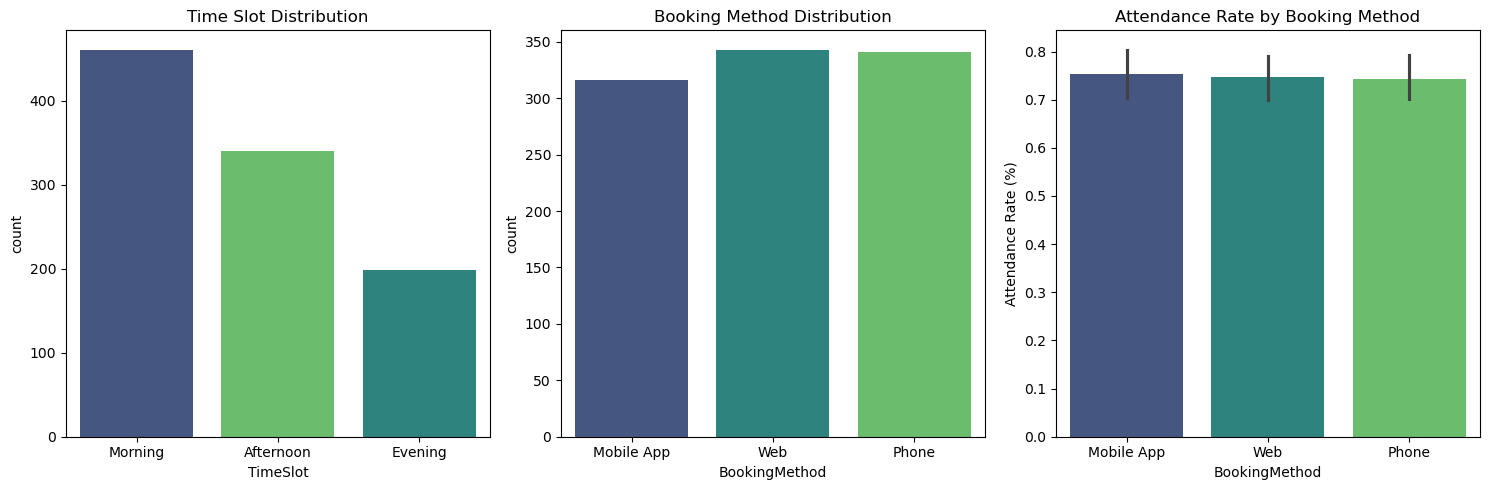

In [3]:
# 2. EXPLORATORY DATA ANALYSIS (EDA)
print("\n[*] Running Exploratory Data Analysis...")
df['Attended_Num'] = df['Attended'].map({'Yes': 1, 'No': 0})

plt.figure(figsize=(15, 5))

# Time Slot Distribution
plt.subplot(1, 3, 1)
sns.countplot(data=df, x='TimeSlot', order=['Morning', 'Afternoon', 'Evening'], hue='TimeSlot', palette='viridis', legend=False)
plt.title('Time Slot Distribution')

# Booking Method Distribution
plt.subplot(1, 3, 2)
sns.countplot(data=df, x='BookingMethod', hue='BookingMethod', palette='viridis', legend=False)
plt.title('Booking Method Distribution')

# Attendance Rate by Booking Method
plt.subplot(1, 3, 3)
sns.barplot(data=df, x='BookingMethod', y='Attended_Num', hue='BookingMethod', palette='viridis', legend=False)
plt.title('Attendance Rate by Booking Method')
plt.ylabel('Attendance Rate (%)')

plt.tight_layout()
plt.show()

## Part 2: Proving the Trends (Statistical Testing)

Visuals are helpful, but are these patterns statistically significant, or just random noise? We will use two Chi-Square tests to find out:
1. **Goodness of Fit:** Is there a true preference for certain times of day?
2. **Test of Independence:** Does the way a patient books actually impact whether they show up?

In [5]:
# 3. STATISTICAL TESTING
alpha = 0.05
print("\n[*] Running Statistical Tests...")

# 1. Goodness of Fit (Time Slot Preferences)
n_slots = df['TimeSlot'].nunique()
expected_freq = np.array([len(df) / n_slots] * n_slots)
observed_freq = df['TimeSlot'].value_counts()[['Morning', 'Afternoon', 'Evening']].values

chi2_gof, p_gof = stats.chisquare(f_obs=observed_freq, f_exp=expected_freq)
print(f"\nGoodness of Fit Test (Time Slots)")
print(f"P-value: {p_gof:.4f} -> {'Significant Preference' if p_gof < alpha else 'No Preference'}")

# 2. Test of Independence (Booking Method vs Attendance)
contingency_table = pd.crosstab(df['BookingMethod'], df['Attended'])
chi2_ind, p_ind, _, _ = stats.chi2_contingency(contingency_table)
print(f"\nIndependence Test (Booking vs Attendance)")
print(f"P-value: {p_ind:.4f} -> {'Significantly Related' if p_ind < alpha else 'No Relationship'}")


[*] Running Statistical Tests...

Goodness of Fit Test (Time Slots)
P-value: 0.0000 -> Significant Preference

Independence Test (Booking vs Attendance)
P-value: 0.9462 -> No Relationship


## Part 3: Predicting the Future (Machine Learning)

Now that we understand the historical data, we want to predict future behavior. We'll train a **Logistic Regression** model using the time slot and booking method to predict if a patient is a "No Show" risk. 

By identifying these high-risk appointments, the clinic can send targeted reminders to save time and revenue.

In [7]:
# 4. PREDICTIVE MODELING
print("\n[*] Training Predictive Model (Logistic Regression)...")

# Feature Engineering & Encoding
le = LabelEncoder()
df['TimeSlot_Encoded'] = le.fit_transform(df['TimeSlot'])
df['BookingMethod_Encoded'] = le.fit_transform(df['BookingMethod'])

X = df[['TimeSlot_Encoded', 'BookingMethod_Encoded']]
y = df['Attended'].map({'Yes': 1, 'No': 0})

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Model
model = LogisticRegression(class_weight='balanced')
model.fit(X_train, y_train)

# Evaluate
predictions = model.predict(X_test)
print("\nModel Evaluation:")
print(classification_report(y_test, predictions, target_names=['No Show (0)', 'Attended (1)']))


[*] Training Predictive Model (Logistic Regression)...

Model Evaluation:
              precision    recall  f1-score   support

 No Show (0)       0.30      0.57      0.40        58
Attended (1)       0.73      0.46      0.57       142

    accuracy                           0.49       200
   macro avg       0.51      0.52      0.48       200
weighted avg       0.60      0.49      0.52       200



## Part 4: Conclusion and recommendation

Let's interpret what our analysis and model just told us:

1. **Patient Preferences:** Our EDA and Goodness of Fit test confirm that patients have a strong, statistically significant preference for **Morning** appointments over evenings. 
2. **The "No-Show" Trigger:** Interestingly, our Independence Test showed that the *booking method* (App, Web, or Phone) has **no relationship** with whether a patient actually shows up. 
3. **Model Reality Check:** Because our current features (Time and Booking Method) don't strongly influence attendance, our Logistic Regression model's predictive power is likely weak. 

**Next Steps for the Clinic:**
To build a truly accurate early-warning system for no-shows, we need richer data. In our next iteration, we should collect features like *patient age*, *distance from clinic*, *weather conditions*, and *past no-show history* to give our machine learning model the signal it needs to make strong predictions.